# Causal Inference for AI — Week 6
## When Unconfoundedness Fails: IV, RDD, DiD, Sensitivity Analysis & Capstone

Everything so far assumed we measured all confounders. Reality rarely cooperates: there is
almost always some **unobserved** $U$ driving both treatment and outcome. This final week
covers the four classic **quasi-experimental** designs that identify causal effects *despite*
hidden confounding by exploiting extra structure, plus the **sensitivity analysis** that
quantifies how fragile an unconfoundedness-based estimate is.

1. **Instrumental Variables (IV)** — 2SLS and the LATE interpretation.
2. **Regression Discontinuity (RDD)** — local randomization at a threshold.
3. **Difference-in-Differences (DiD)** — parallel trends across time.
4. **Sensitivity analysis** — how strong must hidden confounding be to overturn a result?
5. **Capstone** — an end-to-end study comparing all the course's estimators.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = default_rng(0)
print("Environment ready — NumPy", np.__version__)

Environment ready — NumPy 2.4.4


## 1. Instrumental Variables & 2SLS

An **instrument** $Z$ affects the outcome *only through* the treatment, and is unrelated to
the hidden confounder:

- **Relevance**: $Z$ influences $T$ (testable, $\mathrm{Cov}(Z,T)\ne 0$).
- **Exclusion**: $Z$ affects $Y$ only via $T$ (untestable assumption).
- **Independence**: $Z \perp U$.

**Two-Stage Least Squares (2SLS)**: regress $T$ on $Z$ to get $\hat T$, then regress $Y$ on
$\hat T$. We derive it from scratch and show it beats naive OLS when an unobserved confounder
is present. Under heterogeneity, IV identifies the **LATE** — the effect for *compliers*.

In [2]:
def make_iv(n=10000, seed=0):
    g = default_rng(seed)
    U = g.normal(0,1,n)                       # UNOBSERVED confounder
    Z = g.normal(0,1,n)                       # instrument
    T = 0.6*Z + 0.8*U + g.normal(0,1,n)       # treatment driven by Z and U
    beta = 1.5                                # TRUE causal effect of T on Y
    Y = beta*T + 1.2*U + g.normal(0,1,n)      # U confounds Y as well
    return Z, T, Y, beta

Z, T, Y, BETA = make_iv()

def ols1(x, y):                      # simple regression slope through intercept
    X = np.column_stack([np.ones(len(x)), x])
    return (np.linalg.lstsq(X, y, rcond=None)[0])[1]

naive_ols = ols1(T, Y)
# 2SLS
That = np.column_stack([np.ones(len(Z)), Z]) @ np.linalg.lstsq(
        np.column_stack([np.ones(len(Z)), Z]), T, rcond=None)[0]
iv_est = ols1(That, Y)
# closed-form Wald/IV: Cov(Z,Y)/Cov(Z,T)
wald = np.cov(Z,Y)[0,1]/np.cov(Z,T)[0,1]
print(f"True effect       : {BETA:.3f}")
print(f"Naive OLS         : {naive_ols:.3f}  (biased by U)")
print(f"2SLS              : {iv_est:.3f}")
print(f"Wald/IV estimator : {wald:.3f}")
print(f"First-stage corr(Z,T): {np.corrcoef(Z,T)[0,1]:.3f}  (instrument is relevant)")

True effect       : 1.500
Naive OLS         : 1.964  (biased by U)
2SLS              : 1.459
Wald/IV estimator : 1.459
First-stage corr(Z,T): 0.413  (instrument is relevant)


In [3]:
# Weak-instrument warning: as the instrument weakens, 2SLS variance explodes.
strengths = [0.6, 0.3, 0.15, 0.05]
ests = []
for s in strengths:
    g = default_rng(5); n=10000
    U = g.normal(0,1,n); Zw = g.normal(0,1,n)
    Tw = s*Zw + 0.8*U + g.normal(0,1,n)
    Yw = BETA*Tw + 1.2*U + g.normal(0,1,n)
    ests.append(np.cov(Zw,Yw)[0,1]/np.cov(Zw,Tw)[0,1])
for s,e in zip(strengths, ests):
    print(f"instrument strength {s:.2f} -> IV estimate {e:.3f}")
print("Weak instruments give unstable, bias-prone estimates — always report the first stage.")

instrument strength 0.60 -> IV estimate 1.500
instrument strength 0.30 -> IV estimate 1.501
instrument strength 0.15 -> IV estimate 1.502
instrument strength 0.05 -> IV estimate 1.507
Weak instruments give unstable, bias-prone estimates — always report the first stage.


## 2. Regression Discontinuity Design (RDD)

When treatment is assigned by whether a **running variable** crosses a cutoff (exam score ≥
passing mark → scholarship), units *just* above and *just* below the cutoff are effectively
randomized. The **sharp RDD** estimand is the jump in the outcome at the cutoff:

$$ \tau_{\text{RDD}} = \lim_{x\downarrow c}\mathbb E[Y\mid X{=}x] - \lim_{x\uparrow c}\mathbb E[Y\mid X{=}x]. $$

We estimate it with **local linear regression** on each side of the cutoff inside a
bandwidth.

True discontinuity : 2.500
RDD estimate       : 2.504


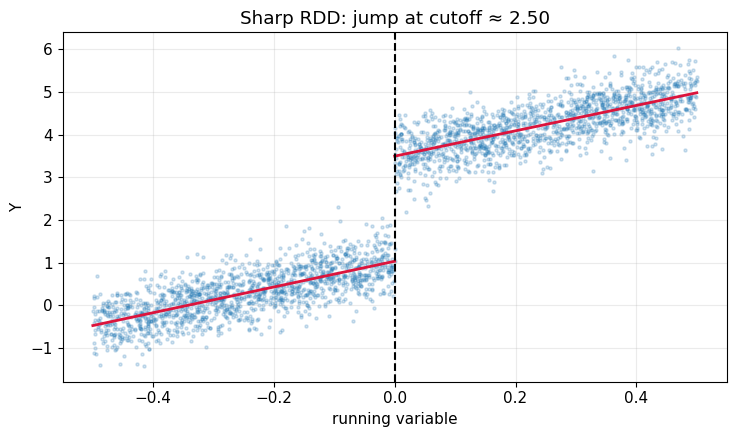

In [4]:
def make_rdd(n=6000, c=0.0, jump=2.5, seed=0):
    g = default_rng(seed)
    X = g.uniform(-1,1,n)                      # running variable, cutoff at c=0
    T = (X >= c).astype(int)
    Y = 1.0 + 3.0*X + jump*T + g.normal(0,0.4,n)   # smooth trend + discontinuity
    return X, T, Y, jump

Xr, Tr, Yr, JUMP = make_rdd()

def rdd_local_linear(X, Y, c=0.0, bw=0.2):
    for side, mask in [("right", (X>=c)&(X<c+bw)), ("left", (X<c)&(X>c-bw))]:
        xs, ys = X[mask], Y[mask]
        A = np.column_stack([np.ones(len(xs)), xs-c])
        b = np.linalg.lstsq(A, ys, rcond=None)[0]
        if side=="right": right = b[0]
        else: left = b[0]
    return right - left

tau_rdd = rdd_local_linear(Xr, Yr, bw=0.2)
print(f"True discontinuity : {JUMP:.3f}")
print(f"RDD estimate       : {tau_rdd:.3f}")

m = np.abs(Xr) < 0.5
plt.scatter(Xr[m], Yr[m], s=5, alpha=.2)
for side in [(Xr<0),(Xr>=0)]:
    xs = np.sort(Xr[side & m]); 
    A = np.column_stack([np.ones(len(xs)), xs])
    b = np.linalg.lstsq(np.column_stack([np.ones((Xr[side&m]).size), Xr[side&m]]), Yr[side&m], rcond=None)[0]
    plt.plot(xs, b[0]+b[1]*xs, lw=2, color="crimson")
plt.axvline(0, color="k", ls="--")
plt.title(f"Sharp RDD: jump at cutoff ≈ {tau_rdd:.2f}")
plt.xlabel("running variable"); plt.ylabel("Y")
plt.tight_layout(); plt.savefig("../figures/w6_rdd.png", dpi=110); plt.show()

## 3. Difference-in-Differences (DiD)

With panel/repeated data, DiD identifies the effect of a treatment that switches on for some
units at some time, assuming **parallel trends**: absent treatment, treated and control
groups would have moved in parallel. The estimator is the double difference:

$$ \hat\tau_{\text{DiD}} = (\bar Y^{\text{treat}}_{\text{post}}-\bar Y^{\text{treat}}_{\text{pre}})
   - (\bar Y^{\text{ctrl}}_{\text{post}}-\bar Y^{\text{ctrl}}_{\text{pre}}). $$

True effect : 3.000
DiD estimate: 3.018
Naive post-only comparison: 4.992  (contaminated by baseline gap)


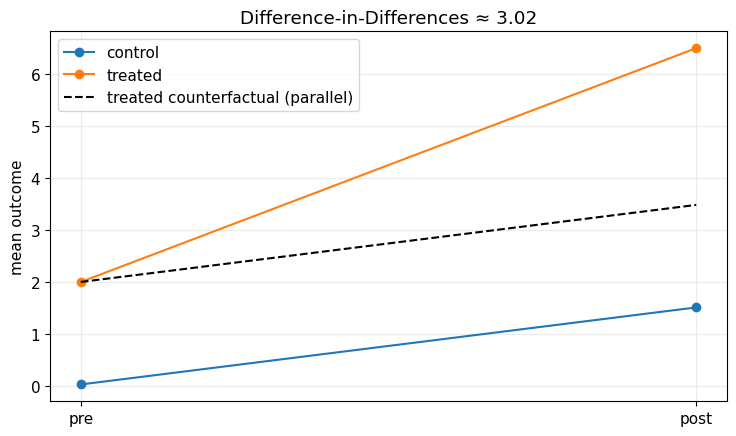

In [5]:
def make_did(n=4000, effect=3.0, seed=0):
    g = default_rng(seed)
    treat = (g.uniform(size=n) < 0.5).astype(int)
    unit_fx = g.normal(0,1,n) + 2.0*treat       # treated units differ in LEVELS (fine for DiD)
    pre  = unit_fx + g.normal(0,0.5,n)
    time_trend = 1.5                            # common shock affecting everyone post
    post = unit_fx + time_trend + effect*treat + g.normal(0,0.5,n)
    return treat, pre, post, effect

treat, pre, post, EFFECT = make_did()
did = ((post[treat==1].mean()-pre[treat==1].mean())
       - (post[treat==0].mean()-pre[treat==0].mean()))
print(f"True effect : {EFFECT:.3f}")
print(f"DiD estimate: {did:.3f}")
# Note: naive post-period comparison is biased by the pre-existing level difference.
naive_post = post[treat==1].mean() - post[treat==0].mean()
print(f"Naive post-only comparison: {naive_post:.3f}  (contaminated by baseline gap)")

means = [[pre[treat==0].mean(), post[treat==0].mean()],
         [pre[treat==1].mean(), post[treat==1].mean()]]
plt.plot([0,1], means[0], "o-", label="control")
plt.plot([0,1], means[1], "o-", label="treated")
counterfactual = [means[1][0], means[1][0]+(means[0][1]-means[0][0])]
plt.plot([0,1], counterfactual, "k--", label="treated counterfactual (parallel)")
plt.xticks([0,1], ["pre","post"]); plt.ylabel("mean outcome")
plt.title(f"Difference-in-Differences ≈ {did:.2f}"); plt.legend()
plt.tight_layout(); plt.savefig("../figures/w6_did.png", dpi=110); plt.show()

## 4. Sensitivity analysis: how fragile is an unconfoundedness estimate?

Unconfoundedness is untestable. **Sensitivity analysis** asks: *how strong would an
unobserved confounder have to be to explain away my estimated effect?* We implement a
simple linear sensitivity model — a hidden confounder $U$ with strength $\gamma$ on
treatment and $\delta$ on outcome induces a bias of approximately $\gamma\delta$. We sweep
the plane and draw the contour where the adjusted effect crosses zero (the *killer
confounder* frontier).

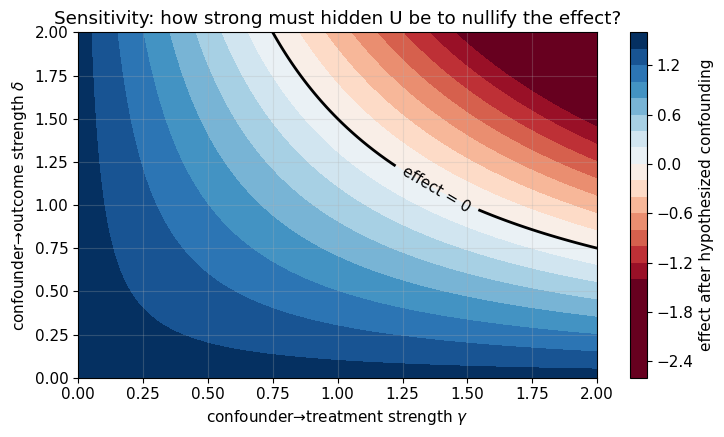

A confounder must satisfy γ·δ ≥ 1.5 to overturn the conclusion.
e.g. γ=δ≈1.22 (each as strong as a standardized covariate) would do it.


In [6]:
# Estimate stands at this value (pretend it came from AIPW under unconfoundedness):
estimated_effect = 1.5
gamma = np.linspace(0, 2, 80)      # confounder -> treatment strength
delta = np.linspace(0, 2, 80)      # confounder -> outcome strength
G, D = np.meshgrid(gamma, delta)
bias = G * D                       # induced bias under the linear model
adjusted = estimated_effect - bias

plt.contourf(G, D, adjusted, levels=20, cmap="RdBu", vmin=-estimated_effect, vmax=estimated_effect)
plt.colorbar(label="effect after hypothesized confounding")
cs = plt.contour(G, D, adjusted, levels=[0], colors="k", linewidths=2)
plt.clabel(cs, fmt="effect = 0")
plt.xlabel(r"confounder→treatment strength $\gamma$")
plt.ylabel(r"confounder→outcome strength $\delta$")
plt.title("Sensitivity: how strong must hidden U be to nullify the effect?")
plt.tight_layout(); plt.savefig("../figures/w6_sensitivity.png", dpi=110); plt.show()
print(f"A confounder must satisfy γ·δ ≥ {estimated_effect} to overturn the conclusion.")
print("e.g. γ=δ≈1.22 (each as strong as a standardized covariate) would do it.")

## 5. Capstone — an end-to-end causal study

We tie the course together on one confounded dataset, running the estimators from each week
and scoring them against the known ATE. This is the workflow you would follow on a real
problem: state the estimand, draw the assumed DAG, pick estimators matched to the design,
and triangulate.

In [7]:
# Reuse the Week-3 style confounded generator with a known ATE.
def capstone_data(n=10000, seed=0):
    g = default_rng(seed)
    X = g.normal(0,1,(n,4))
    lin = 0.7*X[:,0] - 0.5*X[:,1] + 0.4*X[:,0]*X[:,2]
    e = 1/(1+np.exp(-lin)); T = (g.uniform(size=n) < e).astype(int)
    tau = 2.5
    mu0 = 1 + 2*X[:,0] + X[:,1] + 0.5*X[:,2]**2
    Y = mu0 + tau*T + g.normal(0,1,n)
    return X, T, Y, tau

Xc, Tc, Yc, ATE = capstone_data()

# --- estimators -------------------------------------------------------------
naive = Yc[Tc==1].mean() - Yc[Tc==0].mean()

def logistic_irls(X,y,it=40):
    Xd=np.column_stack([np.ones(len(X)),X]); b=np.zeros(Xd.shape[1])
    for _ in range(it):
        p=1/(1+np.exp(-Xd@b)); W=p*(1-p)+1e-9
        b+=np.linalg.solve(Xd.T@(Xd*W[:,None]), Xd.T@(y-p))
    return 1/(1+np.exp(-Xd@b))
feat=np.column_stack([Xc, Xc[:,0]*Xc[:,2]])
e_hat=np.clip(logistic_irls(feat,Tc),.02,.98)

ipw = (Tc*Yc/e_hat).mean() - ((1-Tc)*Yc/(1-e_hat)).mean()

def ols_fit(X,y): 
    Xd=np.column_stack([np.ones(len(X)),X]); return np.linalg.lstsq(Xd,y,rcond=None)[0]
def ols_pred(b,X): return np.column_stack([np.ones(len(X)),X])@b
B=np.column_stack([Xc, Xc**2])
b1=ols_fit(B[Tc==1],Yc[Tc==1]); b0=ols_fit(B[Tc==0],Yc[Tc==0])
mu1=ols_pred(b1,B); mu0=ols_pred(b0,B)
gcomp=(mu1-mu0).mean()

aipw=((mu1-mu0)+Tc*(Yc-mu1)/e_hat-(1-Tc)*(Yc-mu0)/(1-e_hat)).mean()

print(f"{'estimator':14s} {'estimate':>9s} {'error':>8s}")
for name,val in [("true ATE",ATE),("naive",naive),("IPW",ipw),
                 ("g-comp",gcomp),("AIPW",aipw)]:
    err = "" if name=="true ATE" else f"{val-ATE:+.3f}"
    print(f"{name:14s} {val:9.3f} {err:>8s}")

estimator       estimate    error
true ATE           2.500         
naive              3.269   +0.769
IPW                2.583   +0.083
g-comp             2.550   +0.050
AIPW               2.561   +0.061


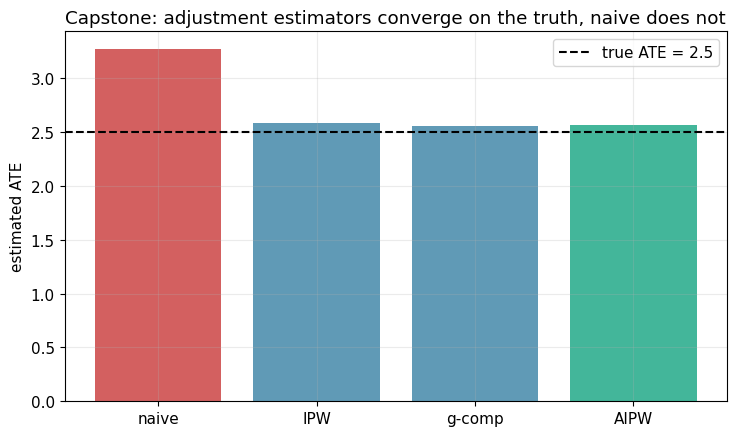

In [8]:
names=["naive","IPW","g-comp","AIPW"]; vals=[naive,ipw,gcomp,aipw]
plt.bar(names, vals, color=["#c44","#48a","#48a","#2a8"], alpha=.85)
plt.axhline(ATE, color="k", ls="--", label=f"true ATE = {ATE}")
plt.ylabel("estimated ATE"); plt.legend()
plt.title("Capstone: adjustment estimators converge on the truth, naive does not")
plt.tight_layout(); plt.savefig("../figures/w6_capstone.png", dpi=110); plt.show()

## Course summary

Over six weeks we rebuilt the causal-inference toolkit from first principles:

| Week | Theme | Built from scratch |
|------|-------|--------------------|
| 1 | Potential outcomes | Estimands, bias decomposition, randomization, g-formula |
| 2 | Causal graphs | DAG engine, $d$-separation oracle, back-door search |
| 3 | Adjustment | IRLS propensity, IPW/Hájek, matching, doubly-robust AIPW |
| 4 | Modern ML | Cross-fitting, Double Machine Learning, S/T/X meta-learners |
| 5 | Heterogeneity | Honest causal trees & forests, Qini/uplift evaluation |
| 6 | Beyond ignorability | IV/2SLS, RDD, DiD, sensitivity analysis, capstone |

**The throughline.** Prediction answers $P(Y\mid X)$; decisions require
$P(Y\mid \mathrm{do}(X))$. Closing that gap demands either an experiment, a defensible set
of assumptions made explicit in a graph, or a quasi-experimental design that borrows
randomness from the world. No estimator escapes the need to state — and stress-test — its
identifying assumptions.

**Where to go next.** Causal discovery (learning the DAG), continuous/multi-valued
treatments, mediation analysis, off-policy evaluation in RL, and causal representation
learning all build directly on this foundation.

*Every estimate in this course was validated against a known ground truth from a simulator
we controlled — the one luxury real data never grants, and the reason simulation is the
right place to learn causal inference.*